In [1]:
%pip install requests numpy pandas matplotlib datetime scipy scikit-learn

Note: you may need to restart the kernel to use updated packages.


## Market Data

In [2]:
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
from sklearn.isotonic import IsotonicRegression
from scipy.interpolate import UnivariateSpline
from scipy.special import logit, expit

In [ ]:
# Fetch active markets
SERIES_TICKER = "KXCPIYOY"
API_BASE = "https://api.elections.kalshi.com/trade-api/v2"

resp = requests.get(f"{API_BASE}/markets", params={"series_ticker": SERIES_TICKER, "status": "open"})
data = resp.json()


In [4]:
# Filter for nearest expiration
df_markets = pd.DataFrame(data['markets'])
df_markets['expiration'] = pd.to_datetime(df_markets['expiration_time'])
target_date = df_markets['expiration'].min()
daily_markets = df_markets[df_markets['expiration'] == target_date]

print(f"Found {len(daily_markets)} markets for expiry: {target_date.date()}")

Found 8 markets for expiry: 2026-03-11


In [ ]:
rows = []
for _, m in daily_markets.iterrows():
    try:
        strike = float(m['subtitle'].replace('>', '').replace('≥', '').replace('%', '').strip())
    except ValueError:
        continue

    ob = requests.get(f"{API_BASE}/markets/{m['ticker']}/orderbook").json()['orderbook']
    
    # Extract best bid/ask
    if ob['yes']:
        yes_bid_price = ob['yes'][-1][0]
        yes_bid_size = ob['yes'][-1][1]
    else:
        yes_bid_price = 0
        yes_bid_size = 0
        
    if ob['no']:
        no_bid_price = ob['no'][-1][0]
        no_bid_size = ob['no'][-1][1]
        yes_ask_price = 100 - no_bid_price
        yes_ask_size = no_bid_size
    else:
        yes_ask_price = 100
        yes_ask_size = 0

    # Weighted micro-price using order book imbalance
    total_size = yes_bid_size + yes_ask_size
    if total_size > 0:
        micro_price = (yes_bid_price * yes_ask_size + yes_ask_price * yes_bid_size) / total_size
    else:
        micro_price = (yes_bid_price + yes_ask_price) / 2

    rows.append({
        'Strike': strike,
        'Bid': yes_bid_price / 100.0,
        'Ask': yes_ask_price / 100.0,
        'Mid': micro_price / 100.0,
        'Liquidity': m.get('liquidity', 0),
        'OpenInterest': m.get('open_interest', 0),
        'Volume': m.get('volume', 0)
    })

df = pd.DataFrame(rows).sort_values('Strike').reset_index(drop=True)


In [6]:
display(df)

,Strike,Bid,Ask,Mid,Liquidity,OpenInterest,Volume
0,2.4,0.99,1.00,1.000000,1303288,60,60
1,2.5,0.98,1.00,1.000000,1305613,165,165
2,2.6,0.98,1.00,1.000000,1309238,163,163
3,2.7,0.97,1.00,1.000000,1402436,2233,4433
4,2.8,0.94,0.96,0.940238,3002609,35177,36362
5,2.9,0.77,0.80,0.778182,5421071,61677,69205
6,3.0,0.42,0.44,0.437500,3365432,14060,21115
7,3.1,0.06,0.10,0.099881,2079048,53240,61848


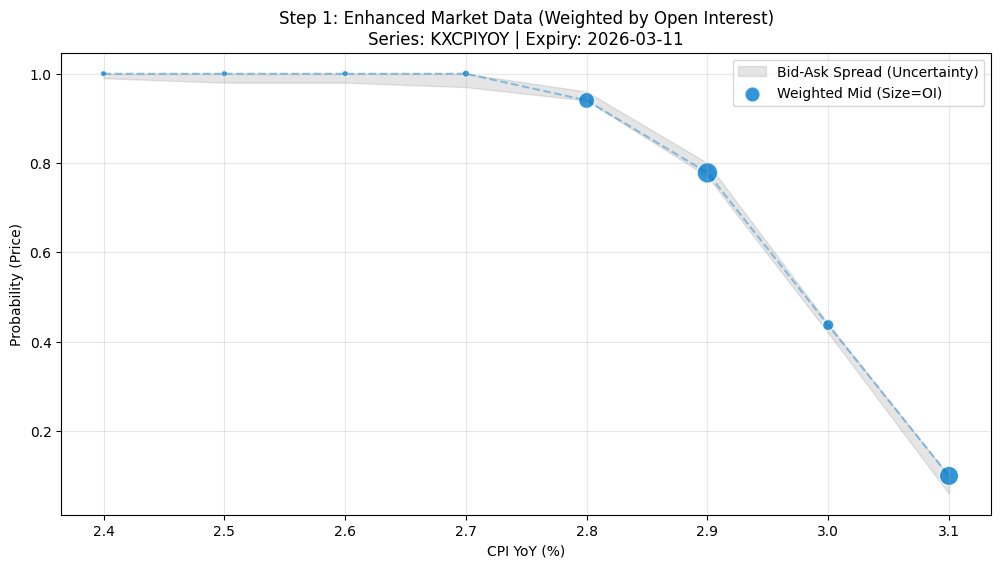

   Strike       Mid   Bid   Ask  OpenInterest
0     2.4  1.000000  0.99  1.00            60
1     2.5  1.000000  0.98  1.00           165
2     2.6  1.000000  0.98  1.00           163
3     2.7  1.000000  0.97  1.00          2233
4     2.8  0.940238  0.94  0.96         35177
5     2.9  0.778182  0.77  0.80         61677
6     3.0  0.437500  0.42  0.44         14060
7     3.1  0.099881  0.06  0.10         53240


In [ ]:
plt.figure(figsize=(12, 6))
plt.title(f"Step 1: Enhanced Market Data (Weighted by Open Interest)\nSeries: {SERIES_TICKER} | Expiry: {target_date.date()}")

plt.fill_between(df['Strike'], df['Bid'], df['Ask'], color='gray', alpha=0.2, label='Bid-Ask Spread (Uncertainty)')

# Size scaled by open interest
oi_sizes = df['OpenInterest']
if oi_sizes.max() > 0:
    plot_sizes = (oi_sizes / oi_sizes.max()) * 200 + 20
else:
    plot_sizes = 50

plt.scatter(df['Strike'], df['Mid'], s=plot_sizes, color='#007acc', alpha=0.8, edgecolors='white', label='Weighted Mid (Size=OI)')
plt.plot(df['Strike'], df['Mid'], color='#007acc', linestyle='--', alpha=0.4)

plt.ylabel("Probability (Price)")
plt.xlabel("CPI YoY (%)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig('step1_market_data.png', dpi=300, bbox_inches='tight')
plt.show()

print(df[['Strike', 'Mid', 'Bid', 'Ask', 'OpenInterest']])


## Cleaning

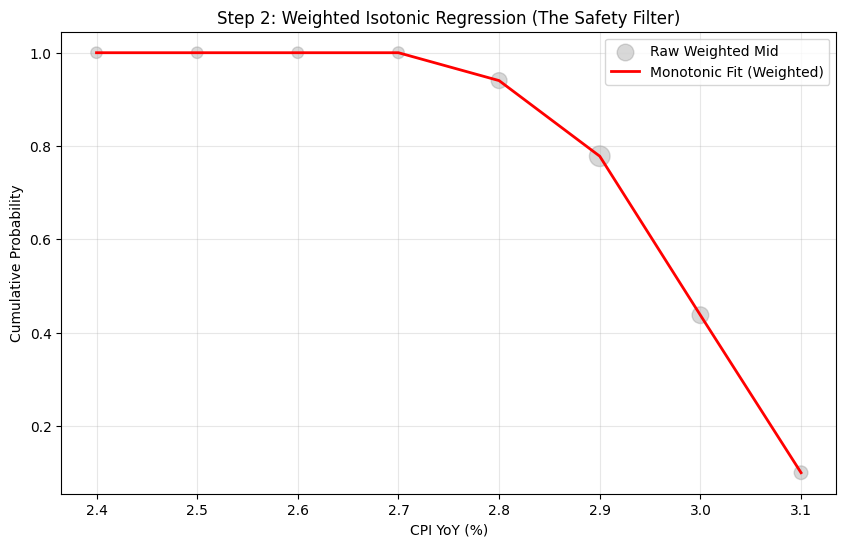

   Strike       Mid  Monotonic_Prob  Liquidity
0     2.4  1.000000        1.000000    1303288
1     2.5  1.000000        1.000000    1305613
2     2.6  1.000000        1.000000    1309238
3     2.7  1.000000        1.000000    1402436
4     2.8  0.940238        0.940238    3002609
5     2.9  0.778182        0.778182    5421071
6     3.0  0.437500        0.437500    3365432
7     3.1  0.099881        0.099881    2079048


In [ ]:
X = df['Strike'].values
y = df['Mid'].values
weights = df['Liquidity'].values + 1e-6

# Weighted isotonic regression (decreasing, since P(>X) drops as X increases)
iso_reg = IsotonicRegression(increasing=False, out_of_bounds='clip')
y_monotonic = iso_reg.fit_transform(X, y, sample_weight=weights)

df['Monotonic_Prob'] = y_monotonic

plt.figure(figsize=(10, 6))
plt.title("Step 2: Weighted Isotonic Regression (The Safety Filter)")

plt.scatter(df['Strike'], df['Mid'], s=(weights/weights.max())*200 + 20, 
            color='gray', alpha=0.3, label='Raw Weighted Mid')

plt.plot(df['Strike'], df['Monotonic_Prob'], color='red', linewidth=2, label='Monotonic Fit (Weighted)')

plt.ylabel("Cumulative Probability")
plt.xlabel("CPI YoY (%)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig('step2_isotonic.png', dpi=300, bbox_inches='tight')
plt.show()

print(df[['Strike', 'Mid', 'Monotonic_Prob', 'Liquidity']])


## Smoothing

Total Probability Mass: 1.0000
Market Implied Expected Value: 2.9898%


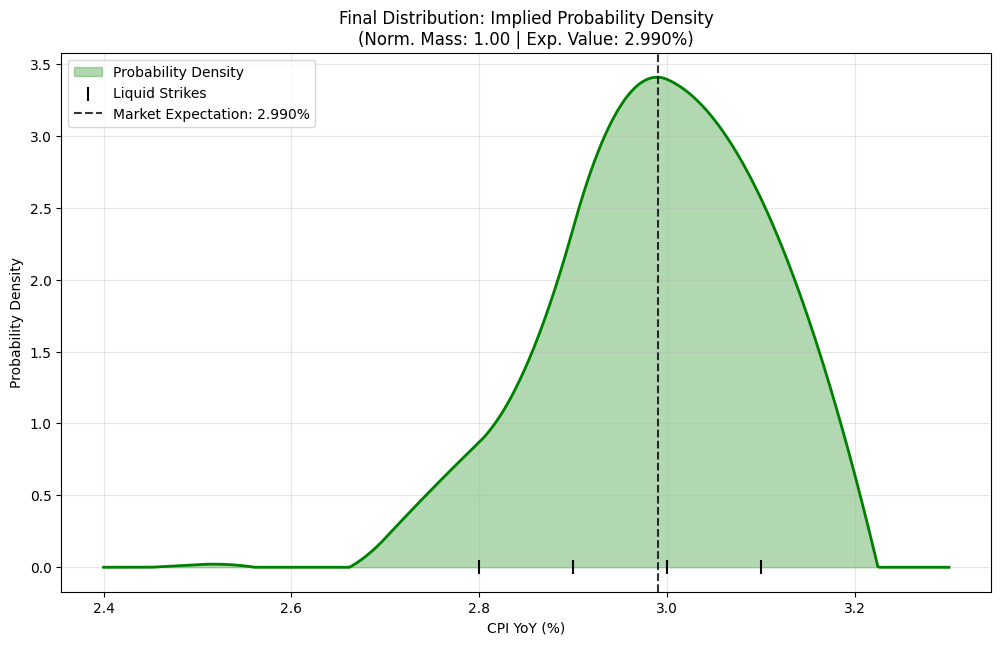

In [ ]:
# Add anchor points for tail control
max_strike = df['Strike'].max()
anchors = pd.DataFrame([
    {'Strike': 0.0, 'Monotonic_Prob': 1.0, 'Liquidity': 1e9},
    {'Strike': max_strike + 0.2, 'Monotonic_Prob': 0.0, 'Liquidity': 1e9} 
])

df_spline = pd.concat([df[['Strike', 'Monotonic_Prob', 'Liquidity']], anchors]).sort_values('Strike')

# Weighted spline fit
cdf_spline = UnivariateSpline(
    df_spline['Strike'], 
    1 - df_spline['Monotonic_Prob'], 
    w=df_spline['Liquidity'] + 1.0, 
    k=3, 
    s=0.001
)

# Extract and normalize PDF
x_grid = np.linspace(df['Strike'].min(), max_strike + 0.2, 500)
pdf_series = cdf_spline.derivative()(x_grid)
pdf_series = np.maximum(pdf_series, 0)
total_area = np.trapezoid(pdf_series, x_grid)
pdf_series = pdf_series / total_area

# Calculate statistics
total_mass = np.trapezoid(pdf_series, x_grid)
expected_val = np.trapezoid(x_grid * pdf_series, x_grid)

print(f"Total Probability Mass: {total_mass:.4f}")
print(f"Market Implied Expected Value: {expected_val:.4f}%")

# Visualization
fig, ax1 = plt.subplots(figsize=(12, 7))

ax1.set_title(f"Final Distribution: Implied Probability Density\n(Norm. Mass: {total_mass:.2f} | Exp. Value: {expected_val:.3f}%)")
ax1.fill_between(x_grid, pdf_series, color='green', alpha=0.3, label='Probability Density')
ax1.plot(x_grid, pdf_series, color='green', linewidth=2)

# Mark liquid strikes
liquid_strikes = df[df['Liquidity'] > df['Liquidity'].quantile(0.5)]['Strike']
ax1.scatter(liquid_strikes, [0]*len(liquid_strikes), color='black', marker='|', s=100, label='Liquid Strikes', zorder=10)

ax1.axvline(expected_val, color='black', linestyle='--', alpha=0.8, label=f'Market Expectation: {expected_val:.3f}%')

ax1.set_ylabel('Probability Density')
ax1.set_xlabel('CPI YoY (%)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)
plt.savefig('step3_final_pdf.png', dpi=300, bbox_inches='tight')
plt.show()
